In [5]:
import matplotlib.image as mpimg
from scipy.spatial import distance
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pymol import cmd
import pymol
import os

In [25]:
# Define some paths
root = '../../../Documents_GPU/mtb-targeted-protein-degradation/notebooks'

# Load pocket detection data
pocket_detection_data = pd.read_csv(os.path.join(root, "..", "processed", "pocket_detection_data.csv"))

# Uniprot to gene name
uniprot_to_gene = pd.read_csv(os.path.join(root, "..", "data", "mtb_trna_synthetases_bosch_2021_fig5.csv"))
uniprot_to_gene = {i: j for i,j in zip(uniprot_to_gene['uniprot_ac'], uniprot_to_gene['gene_name_in_bosch_2021'])}

def get_pockets_to_display(df, thr=6.14):
    pockets = {}
    for fn, pn, ps, coord in df[['File name', 'Pocket number', 'Pocket score', 'Pocket centroid coordinate (x y z)']].values:
        label = fn.replace(".pdb", "") + "_pocket_" + str(pn)
        coords = np.array(coord.split(), dtype=float)
        keep = True
        for pocket in pockets:
            if distance.euclidean(coords, pockets[pocket][0]) < thr:
                keep = False
                break
        if keep:
            pockets[label] = [coords, ps]
    return pockets

def zoom_to_fixed_box(selection="structure", box_size=30.0, box_name="_zoom_box"):
    (xmin, ymin, zmin), (xmax, ymax, zmax) = cmd.get_extent(selection)
    cx = 0.5 * (xmin + xmax)
    cy = 0.5 * (ymin + ymax)
    cz = 0.5 * (zmin + zmax)

    h = box_size / 2.0

    cmd.delete(box_name)

    corners = [
        (cx-h, cy-h, cz-h),
        (cx-h, cy-h, cz+h),
        (cx-h, cy+h, cz-h),
        (cx-h, cy+h, cz+h),
        (cx+h, cy-h, cz-h),
        (cx+h, cy-h, cz+h),
        (cx+h, cy+h, cz-h),
        (cx+h, cy+h, cz+h),
    ]

    for i, (x, y, z) in enumerate(corners):
        cmd.pseudoatom(f"{box_name}_{i}", pos=[x, y, z])

    cmd.group(box_name, f"{box_name}_*")
    cmd.zoom(box_name, buffer=0.0, complete=1)

    # cleanup
    cmd.delete(box_name)
    cmd.delete(f"{box_name}_*")

PROTEINS = sorted(set(pocket_detection_data['Uniprot AC']))
PROTEINS = np.array(PROTEINS)[np.argsort([uniprot_to_gene[i] for i in PROTEINS])]
PATH_TO_OUTPUT = "/home/acomajuncosa/Documents_GPU/tmp"

In [34]:
for protein in PROTEINS:

    # Filter pockets
    df = pocket_detection_data[pocket_detection_data['Uniprot AC'] == protein].sort_values('Pocket score', ascending=False)

    # Select reference structure
    ref_st = df['File name'].tolist()[0]

    # Identify pockets to display
    pockets = get_pockets_to_display(df, thr=12)
    
    # Create pymol session
    pymol.finish_launching(['pymol','-cq'])
    cmd.reinitialize()

    # Load structure
    cmd.load(os.path.join(root, "..", "processed", "aligned_relaxed_structures", protein, ref_st), "structure")
    cmd.set_color("structure_color", [0.7804, 0.8275, 0.8667])
    cmd.color("structure_color", "structure")
    cmd.show("surface", "structure")
    cmd.hide("cartoon", "structure")
    cmd.set("transparency", 0.4, "structure")

    # Load pockets
    path_to_pockets = os.path.join(root, "..", "processed", "detected_pockets")
    for pocket in pockets:
        st = pocket.split("_pocket_")[0]
        pocket_number = pocket.split("_pocket_")[1]
        path_to_pocket = os.path.join(path_to_pockets, protein, st, 'pockets', f"pocket_{pocket_number}.pdb")
        cmd.load(path_to_pocket, pocket)
        cmd.set_color(f"{pocket}_color", [0.9020, 0.6235, 0.0000])
        cmd.color(f"{pocket}_color", pocket)
        cmd.hide("everything", pocket)
        cmd.show("spheres", pocket)
        cmd.set("sphere_transparency", 0.0, pocket)
        cmd.set("sphere_scale", 4, pocket)

    # # Fancy visualization
    cmd.bg_color("white")
    cmd.set("orthoscopic", 1)
    cmd.set("depth_cue", 0)
    cmd.set("ray_trace_fog", 0)
    cmd.set("ray_shadows", 0)
    cmd.set("ray_trace_mode", 1)
    cmd.set("ray_trace_gain", 0.02)
    cmd.set("spec_reflect", 0)
    cmd.set("specular", 0)
    cmd.set("antialias", 2)
    cmd.orient("structure")
    zoom_to_fixed_box("structure", box_size=100)

    cmd.save(os.path.join(PATH_TO_OUTPUT, "session.pse"))
    cmd.ray(1200, 1200)
    cmd.png(os.path.join(PATH_TO_OUTPUT, f"figure_{protein}.png"), dpi=600)

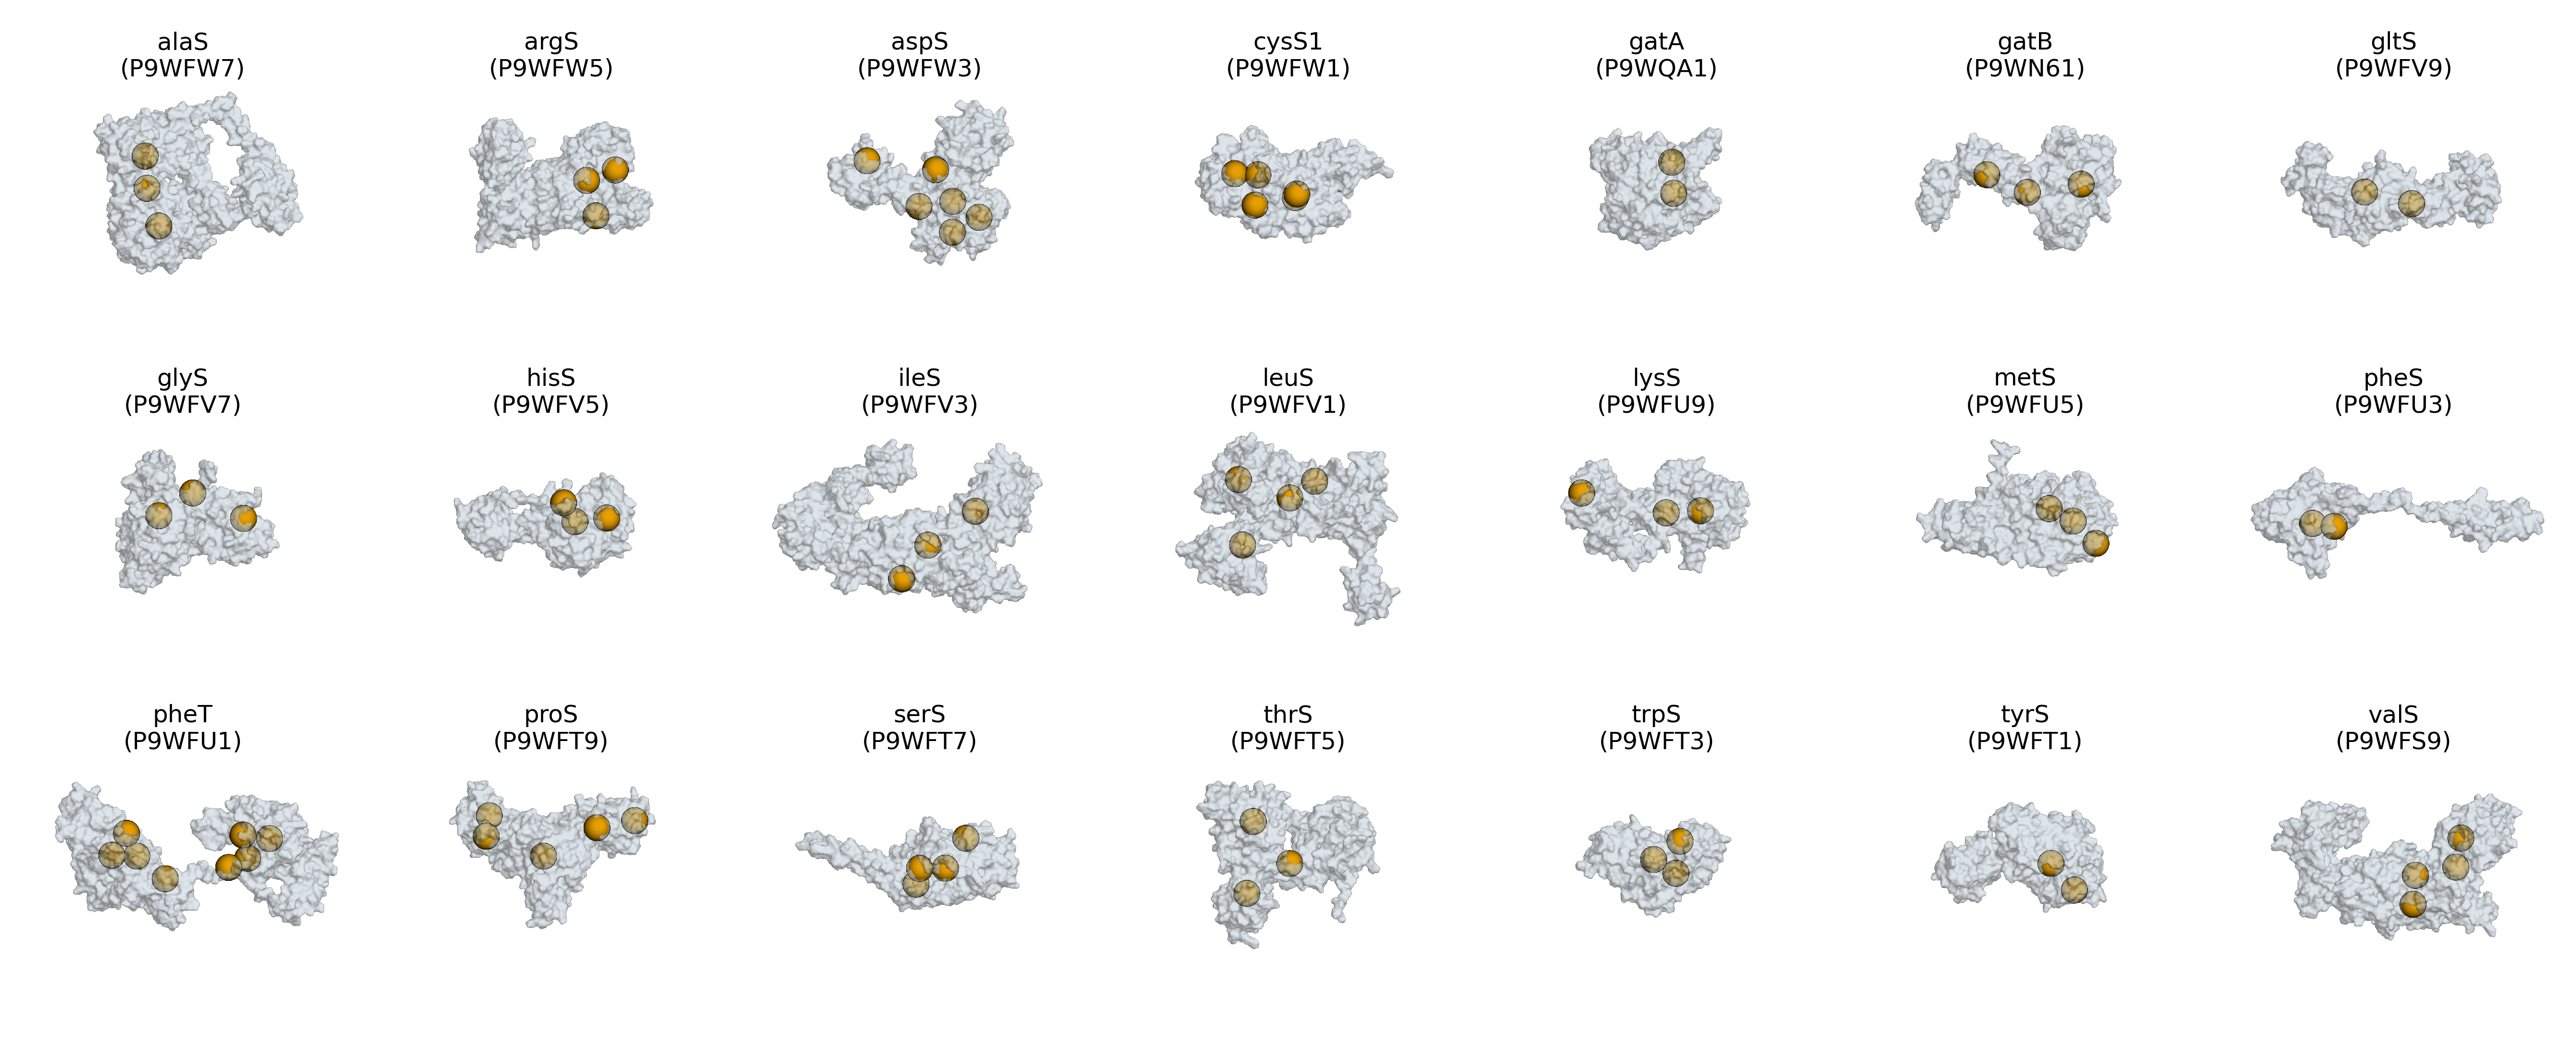

In [53]:
fig, axes = plt.subplots(3, 7, figsize=(18, 7), dpi=300)
axes = axes.ravel()

for ax, protein in zip(axes, PROTEINS):

    file = os.path.join(PATH_TO_OUTPUT, f"figure_{protein}.png")
    ax.imshow(mpimg.imread(file), interpolation='none', resample=False)
    ax.set_axis_off()
    title = f"{uniprot_to_gene[protein]}\n({protein})"
    ax.text(0.5, 0.95, title, transform=ax.transAxes, ha="center", va="top", fontsize=12, color="black", 
            bbox=dict(boxstyle="round,pad=0.2", alpha=0, edgecolor="none")
)

plt.tight_layout(pad=0)
plt.show()
plt.close(fig)